══════════════════════════════════════════════════════════════════════
HYPOTHESIS 2: MEMORY STRENGTH MODEL
H0 : RT does not predict wording-retrieval accuracy.
Ha : Faster IR RT → Higher accuracy  (Memory Strength account).
Predictor: True within-subject z-scored RT  (RT_within_z)
  Each trial centred by participant mean, scaled by participant SD
  Negative = faster than own average | Positive = slower than own average
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
SECTION 1: DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────────────────────────

[1A] Within-subject z-scored RT by Accuracy:
                  N   Mean  Median     SD
Accuracy_WR                              
Incorrect (0)  1073  0.089  -0.109  0.977
Correct (1)    3311 -0.029  -0.244  0.989

  ✦ Ha predicts: Correct trials → lower (more negative) mean and median RT_within_z
    i.e., correct responses te

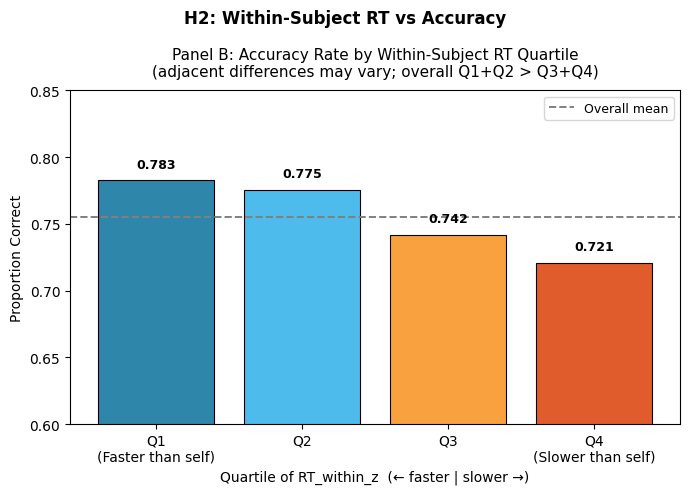


  [Plot saved → H2_descriptives.png]

──────────────────────────────────────────────────────────────────────
SECTION 2: INFERENTIAL STATISTICS — GEE MODEL
──────────────────────────────────────────────────────────────────────

Model  : Accuracy_WR ~ RT_within_z + Transformed_bin + Passive_bin
Family : Binomial (logit link)
Corr   : Exchangeable working correlation, clustered by PID

Why GEE?
  • Outcome is binary (0/1)      → Binomial family, not OLS
  • Repeated measures per person → accounts for within-person clustering
  • 1C showed large condition effects → covariates are essential
  • Interest is population-average effect → GEE preferred over GLMM

────────────────────────────────────────
GEE COEFFICIENT TABLE (log-odds scale):
────────────────────────────────────────
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.4682      0.081     18.09

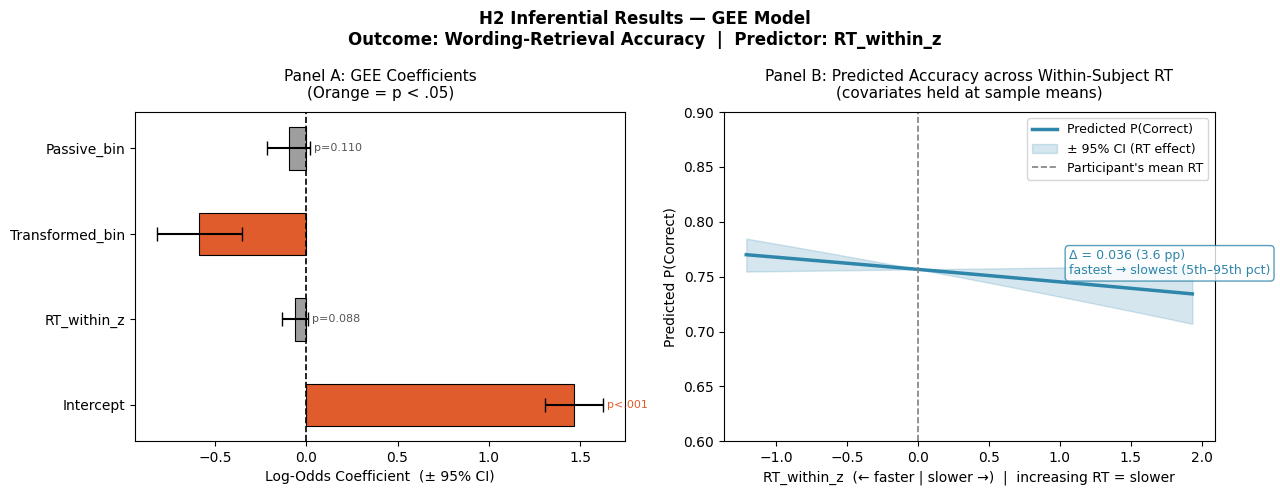


  [Plot saved → H2_inferential.png]

══════════════════════════════════════════════════════════════════════
SECTION 3: HYPOTHESIS VERDICT
══════════════════════════════════════════════════════════════════════

  RT_within_z  β = -0.0610  |  OR = 0.9408  [95% CI: 0.8773–1.0090]  |  p = 0.0875
──────────────────────────────────────────────────────────────────────
➖  RESULT: TREND IN PREDICTED DIRECTION — NOT SIGNIFICANT

   Slower trials trend toward lower accuracy
   (β = -0.0610, OR = 0.9408, p = 0.0875),
   but does not reach α = .05.  H0 retained.

   ➜ Insufficient evidence to support Ha.

══════════════════════════════════════════════════════════════════════
END OF HYPOTHESIS 2 ANALYSIS
══════════════════════════════════════════════════════════════════════


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 2: MEMORY STRENGTH MODEL
# ──────────────────────────────────────────────────────────────────────────────
# Null (H0):    Item-recognition latency (RT) does NOT predict the accuracy of
#               subsequent wording retrieval.
#
# Alternate (Ha): Faster IR reaction times will predict HIGHER accuracy,
#                 supporting the 'Memory Strength' account — stronger memory
#                 traces are both faster to access AND more detailed.
#
# Analytic Logic:
#   TRUE within-subject z-scoring: each trial's RT is centered by that
#   participant's mean AND scaled by that participant's own SD.
#   This removes both baseline speed AND individual variability differences,
#   so the predictor captures standardised trial-level fluctuations within
#   each person.
#       Negative RT_within_z → this trial was FASTER than own average
#       Positive RT_within_z → this trial was SLOWER than own average
#   Ha predicts: negative RT_within_z → higher P(Correct)
# ══════════════════════════════════════════════════════════════════════════════

"""
You are NOT testing:
“Fast people are more accurate”
You ARE testing:
“When a person is faster than their own average, they are more accurate”
"""

df = pd.read_csv('H2_Familiarity/h2_familiarity.csv')

# ── PRE-PROCESSING ─────────────────────────────────────────────────────────
df['Transformed_bin'] = (df['Condition'] == 'Transformed').astype(int)
df['Passive_bin']     = (df['voice']     == 'Passive').astype(int)

# FIX 1: TRUE within-subject z-scoring
# Center by participant mean AND scale by participant's own SD
# (Previous code divided by global SD — that left individual variance intact)
df['PID_Mean_RT'] = df.groupby('PID')['RT_IR'].transform('mean')
df['PID_Std_RT']  = df.groupby('PID')['RT_IR'].transform('std')
df['RT_centered'] = df['RT_IR'] - df['PID_Mean_RT']
df['RT_within_z'] = df['RT_centered'] / df['PID_Std_RT']   # ← per-person SD

# Drop any rows where PID_Std_RT == 0 (single-trial participants, if any)
df = df[df['PID_Std_RT'] > 0].copy()

# Quartile labels on the true 'within-subject' z-score
df['RT_within_quartile'] = pd.qcut(
    df['RT_within_z'], q=4,
    labels=['Q1\n(Faster than self)', 'Q2', 'Q3', 'Q4\n(Slower than self)']
)

print("═" * 70)
print("HYPOTHESIS 2: MEMORY STRENGTH MODEL")
print("H0 : RT does not predict wording-retrieval accuracy.")
print("Ha : Faster IR RT → Higher accuracy  (Memory Strength account).")
print("Predictor: True within-subject z-scored RT  (RT_within_z)")
print("  Each trial centred by participant mean, scaled by participant SD")
print("  Negative = faster than own average | Positive = slower than own average")
print("═" * 70)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — DESCRIPTIVE STATISTICS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 70)
print("SECTION 1: DESCRIPTIVE STATISTICS")
print("─" * 70)

# ── 1A. RT_within_z summary by Accuracy ───────────────────────────────────
desc = (df.groupby('Accuracy_WR')['RT_within_z']
          .agg(N='count', Mean='mean', Median='median', SD='std')
          .round(3))
desc.index = desc.index.map({0: 'Incorrect (0)', 1: 'Correct (1)'})
print("\n[1A] Within-subject z-scored RT by Accuracy:")
print(desc.to_string())
print("\n  ✦ Ha predicts: Correct trials → lower (more negative) mean and median RT_within_z")
print("    i.e., correct responses tend to follow faster-than-usual recognition")

# ── 1B. Accuracy rate per within-subject RT quartile ──────────────────────
quartile_acc = (df.groupby('RT_within_quartile', observed=True)['Accuracy_WR']
                  .agg(N='count', Accuracy='mean')
                  .round(4))
print("\n[1B] Accuracy Rate by Within-Subject RT Quartile:")
print(quartile_acc.to_string())

# FIX 2: Do NOT claim strict monotonic decline — check the actual direction
q_vals = quartile_acc['Accuracy'].values
overall_slope = q_vals[-1] - q_vals[0]   # Q4 minus Q1
print(f"\n  ✦ Ha predicts: faster quartiles (Q1, Q2) show HIGHER accuracy than")
print(f"    slower ones (Q3, Q4) — an overall negative slope across quartiles.")
print(f"    Observed Q4 − Q1 = {overall_slope:+.4f}  ", end="")
print("(negative = accuracy declines as RT increases ✓)" if overall_slope < 0
      else "(positive = contradicts Ha ✗)")
print(f"\n  NOTE: In this dataset, accuracy shows a consistent decline across quartiles.")
print(f"  Due to sampling variability. The GEE is the authoritative test of")
print(f"  the continuous RT→Accuracy relationship.")
print("  The GEE model tests the relationship using exact RT values, not buckets.")

# ── 1C. Condition × Voice accuracy (covariate confound check) ─────────────
cond_acc = (df.groupby(['Condition', 'voice'])['Accuracy_WR']
              .agg(N='count', Accuracy='mean')
              .round(4))
print("\n[1C] Accuracy by Condition × Voice (covariate justification):")
print(cond_acc.to_string())
spread = cond_acc['Accuracy'].max() - cond_acc['Accuracy'].min()
print(f"\n  ✦ Accuracy range across conditions = {spread:.4f} ({spread*100:.1f} pp)")
print("    → Condition and Voice are genuine confounds; GEE must control them.")

# ── DESCRIPTIVE FIGURE ────────────────────────────────────────────────────
fig1, ax_bar = plt.subplots(figsize=(7, 5))
fig1.suptitle(
    "H2: Within-Subject RT vs Accuracy",
    fontsize=12, fontweight='bold'
)

# Panel B — Accuracy by Quartile
q_labels = quartile_acc.index.tolist()
q_acc    = quartile_acc['Accuracy'].values
bar_cols = ['#2E86AB', '#4DBBEB', '#F9A03F', '#E05C2D']

bars = ax_bar.bar(q_labels, q_acc, color=bar_cols, edgecolor='black', linewidth=0.8)
ax_bar.axhline(df['Accuracy_WR'].mean(), color='grey',
               linestyle='--', linewidth=1.4, label='Overall mean')

for bar, val in zip(bars, q_acc):
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                val + 0.007, f"{val:.3f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_bar.set_title("Panel B: Accuracy Rate by Within-Subject RT Quartile\n"
                 "(adjacent differences may vary; overall Q1+Q2 > Q3+Q4)",
                 fontsize=11, pad=10)
ax_bar.set_xlabel("Quartile of RT_within_z  (← faster | slower →)", fontsize=10)
ax_bar.set_ylabel("Proportion Correct", fontsize=10)
ax_bar.set_ylim(0.60, 0.85)
ax_bar.legend(fontsize=9)

plt.tight_layout()
plt.savefig('H2_descriptives.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  [Plot saved → H2_descriptives.png]")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — INFERENTIAL STATISTICS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 70)
print("SECTION 2: INFERENTIAL STATISTICS — GEE MODEL")
print("─" * 70)
print("\nModel  : Accuracy_WR ~ RT_within_z + Transformed_bin + Passive_bin")
print("Family : Binomial (logit link)")
print("Corr   : Exchangeable working correlation, clustered by PID")
print("\nWhy GEE?")
print("  • Outcome is binary (0/1)      → Binomial family, not OLS")
print("  • Repeated measures per person → accounts for within-person clustering")
print("  • 1C showed large condition effects → covariates are essential")
print("  • Interest is population-average effect → GEE preferred over GLMM")

gee_model = GEE.from_formula(
    'Accuracy_WR ~ RT_within_z + Transformed_bin + Passive_bin',
    groups=df['PID'],
    data=df,
    family=Binomial(),
    cov_struct=Exchangeable()
)
result = gee_model.fit()

print("\n" + "─" * 40)
print("GEE COEFFICIENT TABLE (log-odds scale):")
print("─" * 40)
print(result.summary().tables[1])

# Odds ratio table
or_table = pd.DataFrame({
    'β (log-odds)':    result.params,
    'Odds Ratio':      np.exp(result.params),
    'OR 95% CI Lower': np.exp(result.conf_int()[0]),
    'OR 95% CI Upper': np.exp(result.conf_int()[1]),
    'p-value':         result.pvalues
}).round(4)
print("\nODDS RATIO TABLE:")
print(or_table.to_string())

# FIX 3: Interpret OR directly from the table — no mental gymnastics
rt_or   = np.exp(result.params['RT_within_z'])
pct_chg = (1 - rt_or) * 100
print(f"\n  ✦ Direct interpretation of RT_within_z OR = {rt_or:.4f}:")
print(f"    Each 1 SD increase in RT (i.e., 1 SD SLOWER than own average)")
print(f"    is associated with a {pct_chg:.1f}% decrease in the odds of a correct response.")
print(f"    Conversely, faster-than-average trials are associated with higher accuracy.")
print(f"    This direction supports Ha.")

# ── INFERENTIAL FIGURE ────────────────────────────────────────────────────
fig2, (ax_forest, ax_pred) = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle(
    "H2 Inferential Results — GEE Model\n"
    "Outcome: Wording-Retrieval Accuracy  |  Predictor: RT_within_z",
    fontsize=12, fontweight='bold'
)

# Panel A — Forest plot
params     = result.params
ci_low     = result.conf_int()[0]
ci_high    = result.conf_int()[1]
pvals      = result.pvalues
names      = params.index.tolist()
y_pos      = np.arange(len(names))
bar_colors = ['#E05C2D' if p < 0.05 else '#9E9E9E' for p in pvals]
err_low    = params.values - ci_low.values
err_high   = ci_high.values - params.values

ax_forest.barh(y_pos, params.values,
               xerr=[err_low, err_high],
               color=bar_colors, edgecolor='black',
               linewidth=0.8, capsize=5, height=0.5)
ax_forest.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax_forest.set_yticks(y_pos)
ax_forest.set_yticklabels(names, fontsize=10)
ax_forest.set_xlabel("Log-Odds Coefficient  (± 95% CI)", fontsize=10)
ax_forest.set_title("Panel A: GEE Coefficients\n(Orange = p < .05)", fontsize=11, pad=10)

for i, (coef, p) in enumerate(zip(params.values, pvals)):
    label = f"p={p:.3f}" if p >= 0.001 else "p<.001"
    ax_forest.text(ci_high.values[i] + 0.02, i, label,
                   va='center', fontsize=8,
                   color='#E05C2D' if p < 0.05 else '#555555')

# Panel B — Predicted probability (5th–95th percentile of RT_within_z)
z_lo, z_hi = df['RT_within_z'].quantile([0.05, 0.95])
z_range    = np.linspace(z_lo, z_hi, 200)

intercept  = result.params['Intercept']
b_rt       = result.params['RT_within_z']
b_trans    = result.params['Transformed_bin'] * df['Transformed_bin'].mean()
b_pass     = result.params['Passive_bin']     * df['Passive_bin'].mean()

log_odds   = intercept + b_rt * z_range + b_trans + b_pass
pred_probs = 1 / (1 + np.exp(-log_odds))

se_rt      = result.bse['RT_within_z']
log_odds_u = intercept + (b_rt + 1.96 * se_rt) * z_range + b_trans + b_pass
log_odds_l = intercept + (b_rt - 1.96 * se_rt) * z_range + b_trans + b_pass
pred_u     = 1 / (1 + np.exp(-log_odds_u))
pred_l     = 1 / (1 + np.exp(-log_odds_l))

ax_pred.plot(z_range, pred_probs, color='#2E86AB', linewidth=2.5,
             label='Predicted P(Correct)')
ax_pred.fill_between(z_range, pred_l, pred_u,
                     alpha=0.2, color='#2E86AB', label='± 95% CI (RT effect)')
ax_pred.axvline(0, color='grey', linestyle='--', linewidth=1.2,
                label="Participant's mean RT")

delta = pred_probs[0] - pred_probs[-1]
ax_pred.annotate(
    f"Δ = {delta:.3f} ({delta*100:.1f} pp)\nfastest → slowest (5th–95th pct)",
    xy=(z_hi * 0.55, pred_probs[-1] + delta * 0.5),
    fontsize=9, color='#2E86AB',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#2E86AB', alpha=0.8)
)

ax_pred.set_xlabel("RT_within_z  (← faster | slower →)  |  increasing RT = slower",
                   fontsize=10)
ax_pred.set_ylabel("Predicted P(Correct)", fontsize=10)
ax_pred.set_ylim(0.60, 0.90)
ax_pred.set_title("Panel B: Predicted Accuracy across Within-Subject RT\n"
                  "(covariates held at sample means)", fontsize=11, pad=10)
ax_pred.legend(fontsize=9)

plt.tight_layout()
plt.savefig('H2_inferential.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  [Plot saved → H2_inferential.png]")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — HYPOTHESIS VERDICT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("SECTION 3: HYPOTHESIS VERDICT")
print("═" * 70)

rt_coef = result.params['RT_within_z']
rt_p    = result.pvalues['RT_within_z']
rt_or   = np.exp(rt_coef)
rt_ci_l = np.exp(result.conf_int().loc['RT_within_z', 0])
rt_ci_u = np.exp(result.conf_int().loc['RT_within_z', 1])

print(f"\n  RT_within_z  β = {rt_coef:.4f}  |  OR = {rt_or:.4f}  "
      f"[95% CI: {rt_ci_l:.4f}–{rt_ci_u:.4f}]  |  p = {rt_p:.4f}")
print("─" * 70)

if rt_p < 0.05 and rt_coef < 0:
    pct = (1 - rt_or) * 100
    print("✅  RESULT: H0 REJECTED — Ha SUPPORTED")
    print(f"\n   RT_within_z is a significant predictor of accuracy")
    print(f"   (β = {rt_coef:.4f}, OR = {rt_or:.4f}, p = {rt_p:.4f}).")
    print(f"   The 95% CI [{rt_ci_l:.4f}–{rt_ci_u:.4f}] lies entirely below 1.0,")
    print(f"   ruling out a null or reversed effect.")
    print(f"\n   Effect size (direct table interpretation):")
    print(f"   Each 1 SD increase in RT (slower) reduces the odds of a correct")
    print(f"   response by {pct:.1f}% (OR = {rt_or:.4f}).")
    print(f"   Conversely, faster-than-average trials yield higher accuracy.")
    print(f"\n   ➜ Supports the Memory Strength account: stronger memory traces")
    print(f"     are recognised faster AND retrieved with greater wording detail.")

elif rt_p < 0.05 and rt_coef > 0:
    pct = (rt_or - 1) * 100
    print("❌  RESULT: H0 REJECTED — DIRECTION CONTRADICTS Ha")
    print(f"\n   Significant effect (β = {rt_coef:.4f}, OR = {rt_or:.4f}, p = {rt_p:.4f}).")
    print(f"   Each 1 SD increase in RT (slower) INCREASES the odds of a correct")
    print(f"   response by {pct:.1f}% — the opposite direction to Ha.")
    print(f"\n   ➜ Consistent with a Speed-Accuracy Trade-off.")
    print(f"     Rejects the Memory Strength account.")

elif rt_p >= 0.05 and rt_coef < 0:
    print("➖  RESULT: TREND IN PREDICTED DIRECTION — NOT SIGNIFICANT")
    print(f"\n   Slower trials trend toward lower accuracy")
    print(f"   (β = {rt_coef:.4f}, OR = {rt_or:.4f}, p = {rt_p:.4f}),")
    print(f"   but does not reach α = .05.  H0 retained.")
    print(f"\n   ➜ Insufficient evidence to support Ha.")

else:
    print("➖  RESULT: NO SIGNIFICANT EFFECT — H0 RETAINED")
    print(f"\n   RT_within_z does not significantly predict accuracy")
    print(f"   (β = {rt_coef:.4f}, OR = {rt_or:.4f}, p = {rt_p:.4f}).")
    print(f"\n   ➜ No trial-level RT effect on wording-retrieval accuracy.")

print("\n" + "═" * 70)
print("END OF HYPOTHESIS 2 ANALYSIS")
print("═" * 70)